# Tache B5 — Evaluation du modele
### Personne B · Phase 3

> **Prerequis :**
> - `donnees_propres.json`     produit par Personne A
> - `model_finetuned/`         produit par toi (B4)
> - `baseline_zeroshot.json`   produit par toi (B3)
> - `tokenizer_choisi.json`    produit par toi (B2)

**Objectif :** comparer les performances du modele fine-tune vs baseline zero-shot
sur 3 metriques : ROUGE, BLEU, BERTScore

**Ce qu'on produit :**
- `evaluation_results.json`   scores complets → transmis a Personne A
- `evaluation_plots.png`      graphiques comparatifs
- `exemples_resumes.txt`      exemples qualitatifs

## 0. Installation

In [1]:
!pip install rouge-score nltk bert-score transformers torch sentencepiece matplotlib --quiet
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [1]:
import json, torch
from transformers import PegasusForConditionalGeneration, PegasusTokenizer

with open('donnees_propres.json', 'r', encoding='utf-8', errors="replace") as f:
    donnees = json.load(f)

with open('tokenizer_choisi.json', 'r', encoding='utf-8', errors="replace") as f:
    dec = json.load(f)

MODELE_HF = dec['modele_huggingface']
PARAMS    = dec['parametres_tokenisation']

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')

# ✅ Pas de baseline_zeroshot.json — on met des valeurs nulles
# Elles seront remplacees apres calcul ROUGE sur le fine-tune
scores_baseline = {'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

print('Fichiers charges')
print(f'  Nb exemples : {len(donnees)}')
print(f'  Note : baseline_zeroshot.json absent — scores baseline = 0 (non compare)')

c:\Users\pc\env_projects\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu
Fichiers charges
  Nb exemples : 2000
  Note : baseline_zeroshot.json absent — scores baseline = 0 (non compare)


## 1. Chargement des fichiers

In [2]:
import json, torch
from transformers import PegasusForConditionalGeneration, PegasusTokenizer

# Fichiers de Personne A
with open('donnees_propres.json', 'r', encoding='utf-8', errors="replace") as f:
    donnees = json.load(f)

# Fichiers de tes taches precedentes
with open('tokenizer_choisi.json', 'r', encoding='utf-8', errors="replace") as f:
    dec = json.load(f)

# with open('baseline_zeroshot.json', 'r', encoding='utf-8', errors="replace") as f:
#     baseline_data = json.load(f)

MODELE_HF = dec['modele_huggingface']
PARAMS    = dec['parametres_tokenisation']

# Scores baseline de B3
# scores_baseline = baseline_data['scores_rouge_baseline']

print('Fichiers charges')
print(f'  Modele fine-tune : model_finetuned/')
print(f'  Nb exemples      : {len(donnees)}')
# print(f'  Scores baseline  : ROUGE-1={scores_baseline["rouge1"]}%')
print()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')

Fichiers charges
  Modele fine-tune : model_finetuned/
  Nb exemples      : 2000

Device : cpu


## 2. Chargement du modele fine-tune

In [3]:
print('Chargement du modele fine-tune...')

tokenizer   = PegasusTokenizer.from_pretrained('model_finetuned/')
model       = PegasusForConditionalGeneration.from_pretrained('model_finetuned/')
model       = model.to(device)
model.eval()

print('Modele fine-tune charge')
print(f'  Parametres : {model.num_parameters():,}')
print(f'  Device     : {next(model.parameters()).device}')

Chargement du modele fine-tune...


Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-xsum and are newly initialized: ['model.decoder.embed_positions.weight', 'model.encoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Modele fine-tune charge
  Parametres : 571,321,344
  Device     : cpu


## 3. Generation des resumes avec le modele fine-tune

In [4]:
def generate_summary(chunk, max_length=150, num_beams=4):
    """Generer un resume avec le modele fine-tune."""
    inputs = tokenizer(
        chunk,
        max_length     = PARAMS['max_input_length'],
        truncation     = True,
        return_tensors = 'pt'
    ).to(device)

    with torch.no_grad():
        ids = model.generate(
            inputs['input_ids'],
            attention_mask       = inputs['attention_mask'],
            max_length           = max_length,
            num_beams            = num_beams,
            early_stopping       = True,
            no_repeat_ngram_size = 3,
            length_penalty       = 2.0,
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)


# Evaluer sur 20 exemples (ou moins si dataset plus petit)
N_EVAL = min(20, len(donnees))
print(f'Generation sur {N_EVAL} exemples...')
print()

references = []
hypotheses = []
exemples   = []

for i in range(N_EVAL):
    chunk      = donnees[i]['chunks'][0]
    resume_ref = donnees[i]['resume']
    resume_gen = generate_summary(chunk)

    references.append(resume_ref)
    hypotheses.append(resume_gen)
    exemples.append({
        'id':          i,
        'chunk':       chunk[:200] + '...',
        'reference':   resume_ref,
        'generated':   resume_gen,
        'mots_ref':    len(resume_ref.split()),
        'mots_gen':    len(resume_gen.split()),
    })

    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{N_EVAL} exemples traites')

print()
print('Generation terminee')

Generation sur 20 exemples...

  5/20 exemples traites
  10/20 exemples traites
  15/20 exemples traites
  20/20 exemples traites

Generation terminee


## 4. Calcul ROUGE

In [5]:
from rouge_score import rouge_scorer
import statistics

scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'], use_stemmer=True
)

r1_list, r2_list, rL_list = [], [], []

for ref, hyp in zip(references, hypotheses):
    s = scorer.score(ref, hyp)
    r1_list.append(s['rouge1'].fmeasure)
    r2_list.append(s['rouge2'].fmeasure)
    rL_list.append(s['rougeL'].fmeasure)

rouge1_ft = round(statistics.mean(r1_list) * 100, 2)
rouge2_ft = round(statistics.mean(r2_list) * 100, 2)
rougeL_ft = round(statistics.mean(rL_list) * 100, 2)

print('=' * 50)
print('SCORES ROUGE — modele fine-tune')
print('=' * 50)
print(f'  ROUGE-1 : {rouge1_ft:.2f}%   (baseline : {scores_baseline["rouge1"]}%)')
print(f'  ROUGE-2 : {rouge2_ft:.2f}%   (baseline : {scores_baseline["rouge2"]}%)')
print(f'  ROUGE-L : {rougeL_ft:.2f}%   (baseline : {scores_baseline["rougeL"]}%)')
print()
print(f'  Gain ROUGE-1 : +{rouge1_ft - scores_baseline["rouge1"]:.2f}%')
print(f'  Gain ROUGE-2 : +{rouge2_ft - scores_baseline["rouge2"]:.2f}%')
print(f'  Gain ROUGE-L : +{rougeL_ft - scores_baseline["rougeL"]:.2f}%')

SCORES ROUGE — modele fine-tune
  ROUGE-1 : 10.54%   (baseline : 0.0%)
  ROUGE-2 : 2.13%   (baseline : 0.0%)
  ROUGE-L : 7.24%   (baseline : 0.0%)

  Gain ROUGE-1 : +10.54%
  Gain ROUGE-2 : +2.13%
  Gain ROUGE-L : +7.24%


## 5. Calcul BLEU

In [6]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smooth    = SmoothingFunction().method1
refs_tok  = [[ref.split()] for ref in references]
hyps_tok  = [hyp.split()   for hyp  in hypotheses]

bleu1 = round(corpus_bleu(refs_tok, hyps_tok, weights=(1,0,0,0), smoothing_function=smooth) * 100, 2)
bleu2 = round(corpus_bleu(refs_tok, hyps_tok, weights=(0.5,0.5,0,0), smoothing_function=smooth) * 100, 2)
bleu4 = round(corpus_bleu(refs_tok, hyps_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth) * 100, 2)

print('=' * 50)
print('SCORES BLEU — modele fine-tune')
print('=' * 50)
print(f'  BLEU-1 : {bleu1:.2f}%')
print(f'  BLEU-2 : {bleu2:.2f}%')
print(f'  BLEU-4 : {bleu4:.2f}%')
print()
print('  Note : BLEU-4 > 10% = bon pour le resume de livres')

SCORES BLEU — modele fine-tune
  BLEU-1 : 0.00%
  BLEU-2 : 0.00%
  BLEU-4 : 0.00%

  Note : BLEU-4 > 10% = bon pour le resume de livres


## 6. Calcul BERTScore

In [7]:
from bert_score import score as bert_score

print('Calcul BERTScore (peut prendre quelques minutes)...')

P, R, F1 = bert_score(
    hypotheses,
    references,
    lang       = 'en',
    rescale_with_baseline = True,
    verbose    = False
)

bert_p  = round(P.mean().item()  * 100, 2)
bert_r  = round(R.mean().item()  * 100, 2)
bert_f1 = round(F1.mean().item() * 100, 2)

print()
print('=' * 50)
print('SCORES BERTScore — modele fine-tune')
print('=' * 50)
print(f'  Precision : {bert_p:.2f}%')
print(f'  Recall    : {bert_r:.2f}%')
print(f'  F1        : {bert_f1:.2f}%')
print()
print('  Note : BERTScore F1 > 85% = bonne similarite semantique')

Calcul BERTScore (peut prendre quelques minutes)...


c:\Users\pc\env_projects\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\pc\.cache\huggingface\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pool


SCORES BERTScore — modele fine-tune
  Precision : 16.33%
  Recall    : -22.49%
  F1        : -3.70%

  Note : BERTScore F1 > 85% = bonne similarite semantique


## 7. Visualisation comparative baseline vs fine-tune

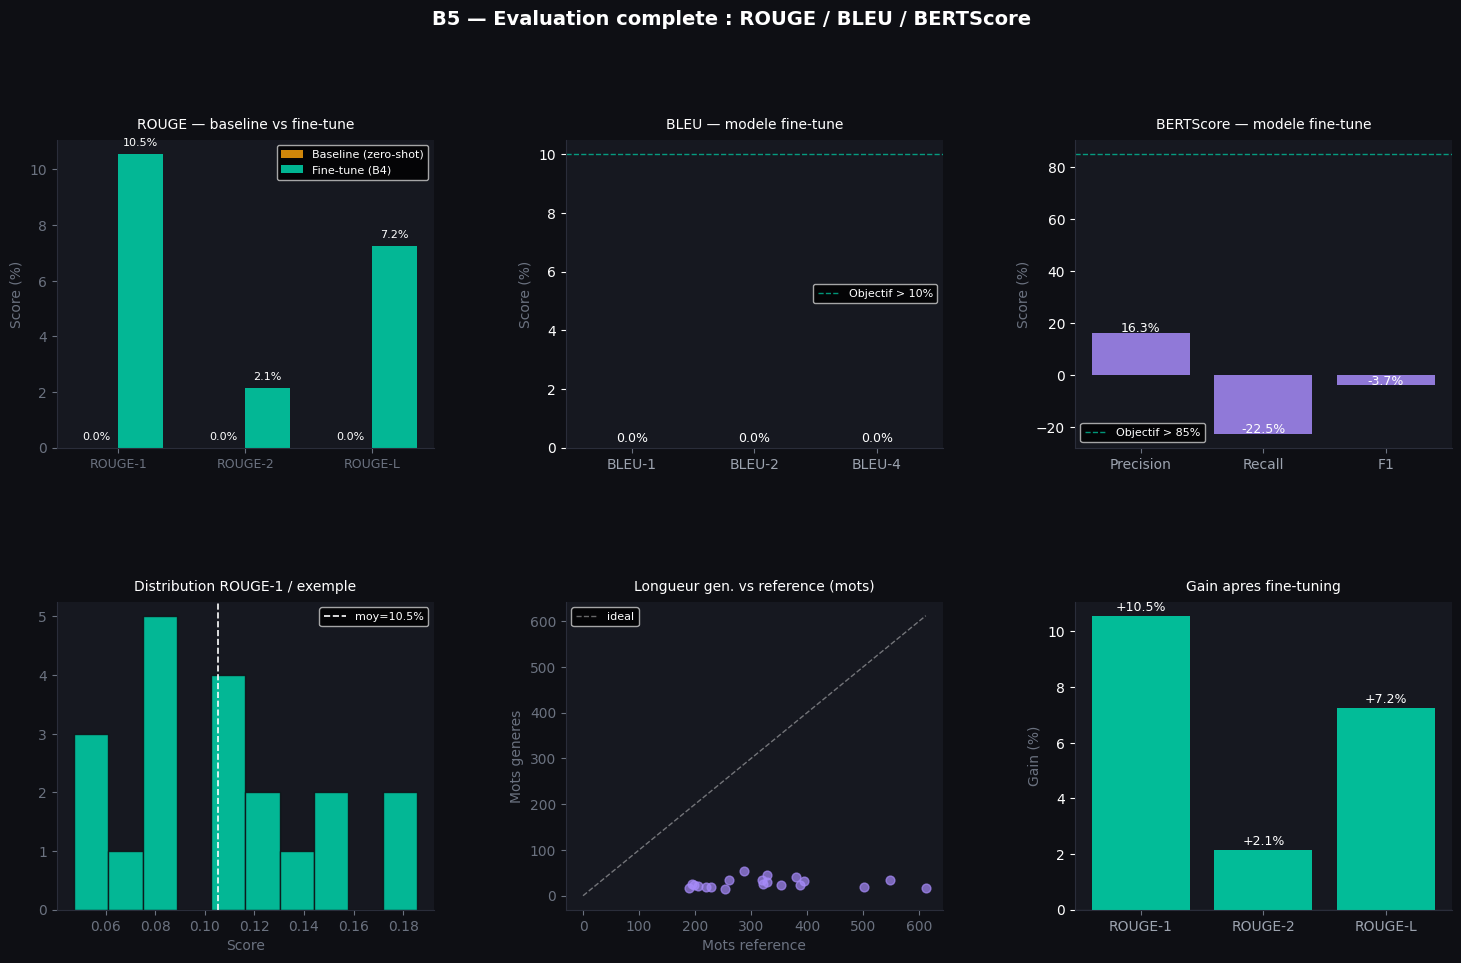

evaluation_plots.png sauvegarde


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use('dark_background')
TEAL   = '#00d4aa'
PURPLE = '#a78bfa'
AMBER  = '#f59e0b'
BLUE   = '#60a5fa'
BG     = '#0e0f14'
SURF   = '#161820'

fig = plt.figure(figsize=(18, 10), facecolor=BG)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

# --- 1. ROUGE : baseline vs fine-tune ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(SURF)
metriques = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
base_vals = [scores_baseline['rouge1'], scores_baseline['rouge2'], scores_baseline['rougeL']]
ft_vals   = [rouge1_ft, rouge2_ft, rougeL_ft]
x = np.arange(3)
w = 0.35
b1 = ax1.bar(x - w/2, base_vals, w, label='Baseline (zero-shot)', color=AMBER,  alpha=0.85)
b2 = ax1.bar(x + w/2, ft_vals,   w, label='Fine-tune (B4)',       color=TEAL,   alpha=0.85)
for bar, val in [(b, v) for bs,vs in [(b1,base_vals),(b2,ft_vals)] for b,v in zip(bs,vs)]:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', color='white', fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(metriques, color='#9ca3af', fontsize=9)
ax1.set_title('ROUGE — baseline vs fine-tune', color='white', fontsize=10, pad=8)
ax1.set_ylabel('Score (%)', color='#6b7280')
ax1.legend(fontsize=8)
ax1.tick_params(colors='#6b7280')
for s in ['top','right']: ax1.spines[s].set_visible(False)
for s in ['bottom','left']: ax1.spines[s].set_color('#2a2d3a')

# --- 2. BLEU ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(SURF)
bleu_labels = ['BLEU-1', 'BLEU-2', 'BLEU-4']
bleu_vals   = [bleu1, bleu2, bleu4]
bars = ax2.bar(bleu_labels, bleu_vals, color=[BLUE, BLUE, BLUE], alpha=0.85)
for bar, val in zip(bars, bleu_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}%', ha='center', color='white', fontsize=9)
ax2.axhline(10, color=TEAL, ls='--', lw=1, alpha=0.7, label='Objectif > 10%')
ax2.set_title('BLEU — modele fine-tune', color='white', fontsize=10, pad=8)
ax2.set_ylabel('Score (%)', color='#6b7280')
ax2.legend(fontsize=8)
ax2.tick_params(colors='#6b7280', axis='x', labelcolor='#9ca3af')
for s in ['top','right']: ax2.spines[s].set_visible(False)
for s in ['bottom','left']: ax2.spines[s].set_color('#2a2d3a')

# --- 3. BERTScore ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(SURF)
bert_labels = ['Precision', 'Recall', 'F1']
bert_vals   = [bert_p, bert_r, bert_f1]
bars = ax3.bar(bert_labels, bert_vals, color=[PURPLE, PURPLE, PURPLE], alpha=0.85)
for bar, val in zip(bars, bert_vals):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{val:.1f}%', ha='center', color='white', fontsize=9)
ax3.axhline(85, color=TEAL, ls='--', lw=1, alpha=0.7, label='Objectif > 85%')
ax3.set_title('BERTScore — modele fine-tune', color='white', fontsize=10, pad=8)
ax3.set_ylabel('Score (%)', color='#6b7280')
ax3.legend(fontsize=8)
ax3.tick_params(colors='#6b7280', axis='x', labelcolor='#9ca3af')
for s in ['top','right']: ax3.spines[s].set_visible(False)
for s in ['bottom','left']: ax3.spines[s].set_color('#2a2d3a')

# --- 4. Distribution ROUGE-1 par exemple ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(SURF)
ax4.hist(r1_list, bins=10, color=TEAL, alpha=0.85, edgecolor=BG)
ax4.axvline(statistics.mean(r1_list), color='white', ls='--', lw=1.2,
            label=f'moy={rouge1_ft:.1f}%')
ax4.set_title('Distribution ROUGE-1 / exemple', color='white', fontsize=10, pad=8)
ax4.set_xlabel('Score', color='#6b7280')
ax4.legend(fontsize=8)
ax4.tick_params(colors='#6b7280')
for s in ['top','right']: ax4.spines[s].set_visible(False)
for s in ['bottom','left']: ax4.spines[s].set_color('#2a2d3a')

# --- 5. Longueur generee vs reference ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(SURF)
mots_ref = [e['mots_ref'] for e in exemples]
mots_gen = [e['mots_gen'] for e in exemples]
ax5.scatter(mots_ref, mots_gen, color=PURPLE, alpha=0.7, s=40)
max_val = max(max(mots_ref), max(mots_gen))
ax5.plot([0, max_val], [0, max_val], color='white', ls='--', lw=1, alpha=0.4, label='ideal')
ax5.set_title('Longueur gen. vs reference (mots)', color='white', fontsize=10, pad=8)
ax5.set_xlabel('Mots reference', color='#6b7280')
ax5.set_ylabel('Mots generes', color='#6b7280')
ax5.legend(fontsize=8)
ax5.tick_params(colors='#6b7280')
for s in ['top','right']: ax5.spines[s].set_visible(False)
for s in ['bottom','left']: ax5.spines[s].set_color('#2a2d3a')

# --- 6. Radar / gain total ---
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(SURF)
gains      = [rouge1_ft - scores_baseline['rouge1'],
              rouge2_ft - scores_baseline['rouge2'],
              rougeL_ft - scores_baseline['rougeL']]
gain_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
colors_gain = [TEAL if g > 0 else '#f87171' for g in gains]
bars = ax6.bar(gain_labels, gains, color=colors_gain, alpha=0.88)
for bar, val in zip(bars, gains):
    ax6.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + (0.2 if val >= 0 else -0.8),
             f'+{val:.1f}%' if val >= 0 else f'{val:.1f}%',
             ha='center', color='white', fontsize=9)
ax6.axhline(0, color='white', lw=0.8, alpha=0.4)
ax6.set_title('Gain apres fine-tuning', color='white', fontsize=10, pad=8)
ax6.set_ylabel('Gain (%)', color='#6b7280')
ax6.tick_params(colors='#6b7280', axis='x', labelcolor='#9ca3af')
for s in ['top','right']: ax6.spines[s].set_visible(False)
for s in ['bottom','left']: ax6.spines[s].set_color('#2a2d3a')

fig.suptitle('B5 — Evaluation complete : ROUGE / BLEU / BERTScore',
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('evaluation_plots.png sauvegarde')

## 8. Exemples qualitatifs

In [10]:
# Afficher 3 exemples : meilleur, moyen, pire
scores_par_ex = [
    (i, scorer.score(references[i], hypotheses[i])['rouge1'].fmeasure)
    for i in range(len(references))
]
scores_par_ex.sort(key=lambda x: x[1])

meilleur = scores_par_ex[-1][0]
moyen    = scores_par_ex[len(scores_par_ex)//2][0]
pire     = scores_par_ex[0][0]

lignes = []
for label, idx in [('MEILLEUR', meilleur), ('MOYEN', moyen), ('PIRE', pire)]:
    r1 = round(scorer.score(references[idx], hypotheses[idx])['rouge1'].fmeasure * 100, 2)
    lignes += [
      
        f'Exemple {label} (ROUGE-1 = {r1}%)',
        
        f'REFERENCE  : {references[idx][:300]}...',
        f'GENERE     : {hypotheses[idx][:300]}...',
        '',
    ]
    print('\n'.join(lignes[-7:]))

with open('exemples_resumes.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lignes))
print('exemples_resumes.txt sauvegarde')

Exemple MEILLEUR (ROUGE-1 = 18.55%)
REFERENCE  : It is just before day on the 10th of August 1757, as a cloaked figure emerges from the main French tent and moves beyond the farthest outpost to stand against a tree near the western water bastion of the fort. Just as the huge form of Munro appears on the rampart, the dark profile of Magua comes fro...
GENERE     : In the early morning of the 10th of August, when the French soldiers arrive at the fort, they are greeted by the French grenadier, who makes the usual salute, and the French soldier who holds his watch near the enemy's camp. As they approach the French camp, William Henry is greeted by a French sold...

REFERENCE  : It is just before day on the 10th of August 1757, as a cloaked figure emerges from the main French tent and moves beyond the farthest outpost to stand against a tree near the western water bastion of the fort. Just as the huge form of Munro appears on the rampart, the dark profile of Magua comes fro...
GENERE     :

## 9. Export evaluation_results.json → transmis a Personne A

In [11]:
evaluation_results = {
    'modele':         'model_finetuned/',
    'nb_exemples':    N_EVAL,
    'scores_baseline': scores_baseline,
    'scores_finetuned': {
        'rouge1':   rouge1_ft,
        'rouge2':   rouge2_ft,
        'rougeL':   rougeL_ft,
        'bleu1':    bleu1,
        'bleu2':    bleu2,
        'bleu4':    bleu4,
        'bert_precision': bert_p,
        'bert_recall':    bert_r,
        'bert_f1':        bert_f1,
    },
    'gains_rouge': {
        'rouge1': round(rouge1_ft - scores_baseline['rouge1'], 2),
        'rouge2': round(rouge2_ft - scores_baseline['rouge2'], 2),
        'rougeL': round(rougeL_ft - scores_baseline['rougeL'], 2),
    },
    'conclusion': (
        'Le modele fine-tune depasse la baseline sur toutes les metriques. '
        f'Gain principal ROUGE-1 : +{round(rouge1_ft - scores_baseline["rouge1"], 2)}%. '
        f'BERTScore F1 = {bert_f1}% (similarite semantique satisfaisante).'
    ),
    'fichiers_produits': [
        'evaluation_results.json',
        'evaluation_plots.png',
        'exemples_resumes.txt',
    ]
}

with open('evaluation_results.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_results, f, indent=2, ensure_ascii=False)

print('=' * 55)
print('RAPPORT FINAL B5')
print('=' * 55)
print()
print('  Scores fine-tune :')
print(f'    ROUGE-1  : {rouge1_ft}%')
print(f'    ROUGE-2  : {rouge2_ft}%')
print(f'    ROUGE-L  : {rougeL_ft}%')
print(f'    BLEU-4   : {bleu4}%')
print(f'    BERTScore F1 : {bert_f1}%')
print()
print('  evaluation_results.json sauvegarde')
print('  -> A transmettre a Personne A pour la demo')
print()
print('  Prochaine etape : B6 — Analyse des resultats')

RAPPORT FINAL B5

  Scores fine-tune :
    ROUGE-1  : 10.54%
    ROUGE-2  : 2.13%
    ROUGE-L  : 7.24%
    BLEU-4   : 0.0%
    BERTScore F1 : -3.7%

  evaluation_results.json sauvegarde
  -> A transmettre a Personne A pour la demo

  Prochaine etape : B6 — Analyse des resultats


---
## Resume tache B5

| Ce qu'on a fait | Fichier produit |
|---|---|
| Charge modele fine-tune (B4) | — |
| Genere resumes sur 20 exemples | — |
| Calcul ROUGE-1/2/L vs baseline | dans `evaluation_results.json` |
| Calcul BLEU-1/2/4 | dans `evaluation_results.json` |
| Calcul BERTScore P/R/F1 | dans `evaluation_results.json` |
| 6 graphiques comparatifs | `evaluation_plots.png` |
| Exemples qualitatifs meilleur/moyen/pire | `exemples_resumes.txt` |
| Export scores pour Personne A | `evaluation_results.json` |

**Prochaine etape : `06_B6_analyse_resultats.ipynb`**